In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('data_fake.csv')

In [5]:
df.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-A,Laptop,145.0,238,Supplier-Z,2025-11-09,2037
1,WH-E,Mobile,NaN,73,Supplier-B,2024-09-25,2261
2,WH-B,Laptop,121.0,229,Supplier-B,2024-07-20,2592
3,WH-D,Monitor,321.0,51,Supplier-A,2026-01-27,3101
4,WH-B,Printer,162.0,245,Supplier-Z,2025-01-30,2308


Phase 1 → Import Libraries 
Phase 2 → Load Dataset
Phase 3 → Basic EDA
Phase 4 → Data Cleaning
Phase 5 → Feature Engineering
Phase 6 → Data Visualization
Phase 7 → Regression Model
Phase 8 → Classification Model
Phase 9 → Model Evaluation
Phase 10 → Prediction on New Data

In [6]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse       200 non-null    object 
 1   Product         200 non-null    object 
 2   Stock Level     182 non-null    float64
 3   Reorder Level   200 non-null    int64  
 4   Supplier        200 non-null    object 
 5   Last Updated    200 non-null    object 
 6   Transport Cost  200 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 11.1+ KB


,Stock Level,Reorder Level,Transport Cost
count,182.000000,200.000000,200.00000
mean,259.521978,148.785000,2520.59500
std,129.944557,58.456605,645.57969
min,20.000000,50.000000,886.00000
25%,155.000000,96.750000,2072.25000
50%,256.000000,148.500000,2519.00000
75%,361.250000,199.250000,2990.75000
max,500.000000,250.000000,4198.00000


Basic EDA 

In [7]:
df.isnull().sum()

Warehouse          0
Product            0
Stock Level       18
Reorder Level      0
Supplier           0
Last Updated       0
Transport Cost     0
dtype: int64

In [8]:
(df.isnull().sum()/len(df))*100

Warehouse         0.0
Product           0.0
Stock Level       9.0
Reorder Level     0.0
Supplier          0.0
Last Updated      0.0
Transport Cost    0.0
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Warehouse           5
Product             8
Stock Level       152
Reorder Level     130
Supplier            5
Last Updated      171
Transport Cost    186
dtype: int64

In [11]:
df["Warehouse"].value_counts()

Warehouse
WH-D    47
WH-E    44
WH-C    39
WH-B    38
WH-A    32
Name: count, dtype: int64

In [12]:
df["Product"].value_counts()

Product
Monitor     35
Mobile      31
Printer     30
Keyboard    29
Camera      23
Laptop      22
Mouse       15
Tablet      15
Name: count, dtype: int64

In [13]:
df["Supplier"].value_counts()

Supplier
Supplier-A    47
Supplier-B    43
Supplier-X    41
Supplier-Y    35
Supplier-Z    34
Name: count, dtype: int64

In [14]:
df["Transport Cost"].describe()

count     200.00000
mean     2520.59500
std       645.57969
min       886.00000
25%      2072.25000
50%      2519.00000
75%      2990.75000
max      4198.00000
Name: Transport Cost, dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

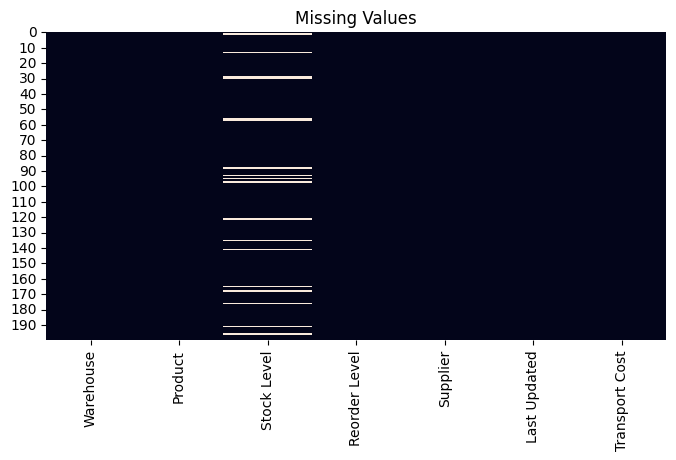

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

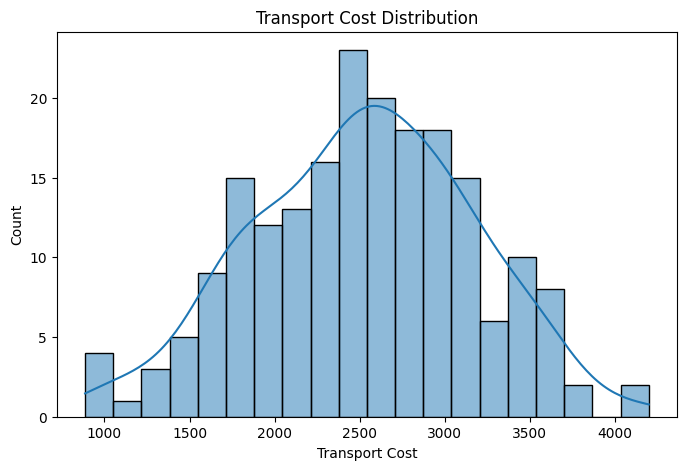

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Transport Cost"],
    bins=20,
    kde=True
)

plt.title("Transport Cost Distribution")

plt.show()

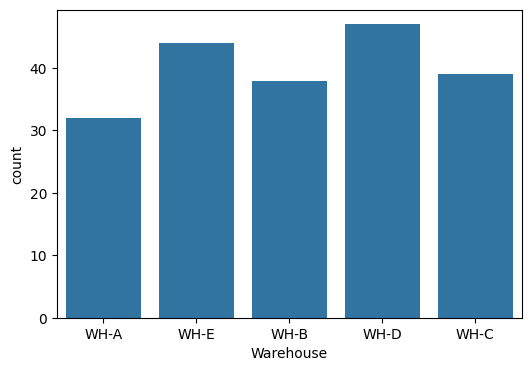

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Warehouse")

plt.show()

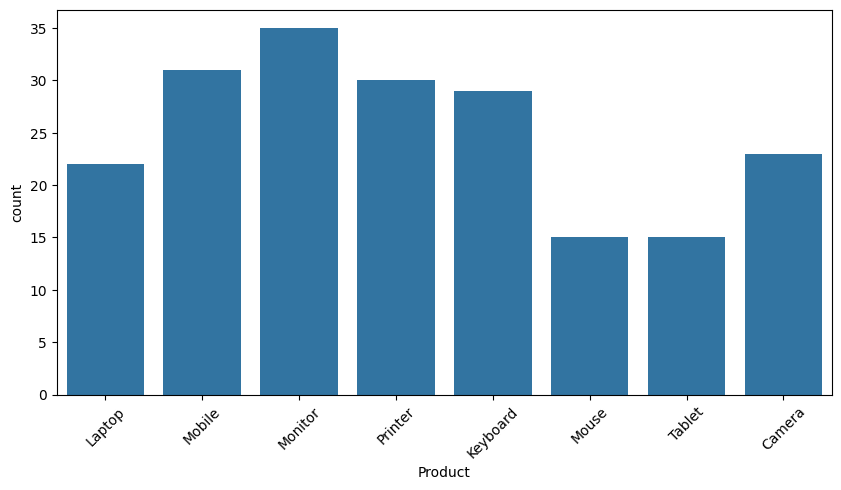

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="Product")

plt.xticks(rotation=45)

plt.show()

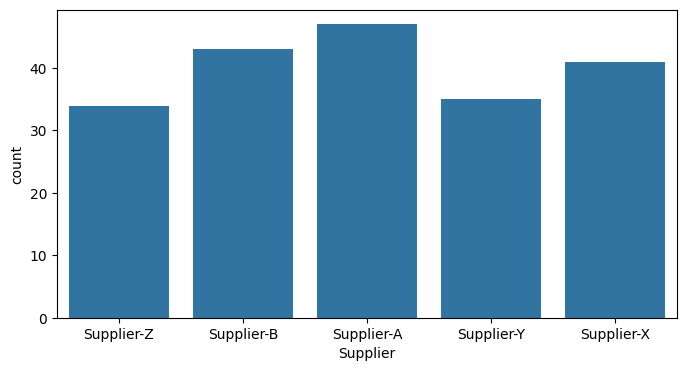

In [20]:
plt.figure(figsize=(8,4))

sns.countplot(data=df,x="Supplier")

plt.show()

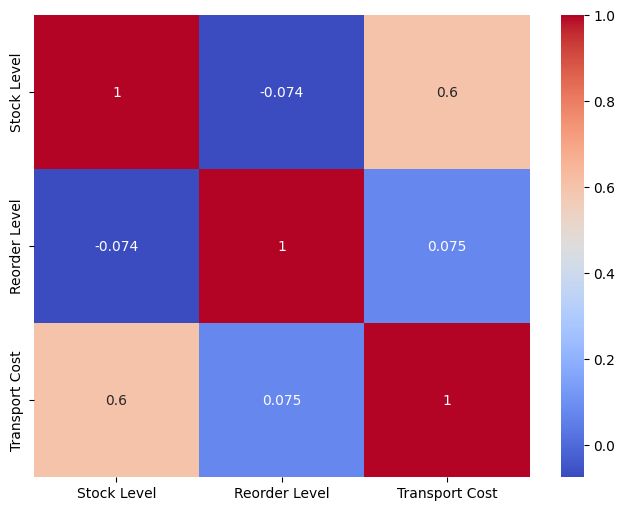

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Data Cleaning 

In [22]:
df_clean = df.copy()

In [23]:
df_clean.isnull().sum()

Warehouse          0
Product            0
Stock Level       18
Reorder Level      0
Supplier           0
Last Updated       0
Transport Cost     0
dtype: int64

In [24]:
df_clean["Stock Level"] = df_clean["Stock Level"].fillna(
    df_clean["Stock Level"].median()
)

In [25]:
df_clean.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-A,Laptop,145.0,238,Supplier-Z,2025-11-09,2037
1,WH-E,Mobile,256.0,73,Supplier-B,2024-09-25,2261
2,WH-B,Laptop,121.0,229,Supplier-B,2024-07-20,2592
3,WH-D,Monitor,321.0,51,Supplier-A,2026-01-27,3101
4,WH-B,Printer,162.0,245,Supplier-Z,2025-01-30,2308


In [26]:
df_clean.isnull().sum()

Warehouse         0
Product           0
Stock Level       0
Reorder Level     0
Supplier          0
Last Updated      0
Transport Cost    0
dtype: int64

In [27]:
print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)

print("After :", df_clean.shape)

Before: (200, 7)
After : (200, 7)


In [28]:
df_clean["Last Updated"] = pd.to_datetime(df_clean["Last Updated"])

In [29]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Warehouse       200 non-null    object        
 1   Product         200 non-null    object        
 2   Stock Level     200 non-null    float64       
 3   Reorder Level   200 non-null    int64         
 4   Supplier        200 non-null    object        
 5   Last Updated    200 non-null    datetime64[ns]
 6   Transport Cost  200 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 11.1+ KB


### Feature Engineering

In [30]:
df_fe = df_clean.copy()

In [31]:
df_fe["Year"] = df_fe["Last Updated"].dt.year
df_fe["Month"] = df_fe["Last Updated"].dt.month
df_fe["Day"] = df_fe["Last Updated"].dt.day
df_fe["Weekday"] = df_fe["Last Updated"].dt.day_name()

In [32]:
df_fe.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost,Year,Month,Day,Weekday
0,WH-A,Laptop,145.0,238,Supplier-Z,2025-11-09,2037,2025,11,9,Sunday
1,WH-E,Mobile,256.0,73,Supplier-B,2024-09-25,2261,2024,9,25,Wednesday
2,WH-B,Laptop,121.0,229,Supplier-B,2024-07-20,2592,2024,7,20,Saturday
3,WH-D,Monitor,321.0,51,Supplier-A,2026-01-27,3101,2026,1,27,Tuesday
4,WH-B,Printer,162.0,245,Supplier-Z,2025-01-30,2308,2025,1,30,Thursday


In [33]:
df_fe["Stock Shortage Risk"] = (
    df_fe["Stock Level"] < df_fe["Reorder Level"]
).astype(int)

In [34]:
df_fe[["Stock Level","Reorder Level","Stock Shortage Risk"]].head(10)

,Stock Level,Reorder Level,Stock Shortage Risk
0,145.0,238,1
1,256.0,73,0
2,121.0,229,1
3,321.0,51,0
4,162.0,245,1
5,69.0,138,1
6,294.0,146,0
7,473.0,197,0
8,415.0,70,0
9,162.0,143,0


In [35]:
df_fe["Stock Shortage Risk"].value_counts()

Stock Shortage Risk
0    156
1     44
Name: count, dtype: int64

In [36]:
df_fe["Stock Shortage Risk"].value_counts(normalize=True)*100

Stock Shortage Risk
0    78.0
1    22.0
Name: proportion, dtype: float64

In [37]:
categorical_columns = [
    "Warehouse",
    "Product",
    "Supplier",
    "Weekday"
]

df_encoded = pd.get_dummies(
    df_fe,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [38]:
df_encoded.head()

,Stock Level,Reorder Level,Last Updated,Transport Cost,Year,Month,Day,Stock Shortage Risk,Warehouse_WH-B,Warehouse_WH-C,Warehouse_WH-D,Warehouse_WH-E,Product_Keyboard,Product_Laptop,Product_Mobile,Product_Monitor,Product_Mouse,Product_Printer,Product_Tablet,Supplier_Supplier-B,Supplier_Supplier-X,Supplier_Supplier-Y,Supplier_Supplier-Z,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday
0,145.0,238,2025-11-09,2037,2025,11,9,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,256.0,73,2024-09-25,2261,2024,9,25,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1
2,121.0,229,2024-07-20,2592,2024,7,20,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
3,321.0,51,2026-01-27,3101,2026,1,27,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
4,162.0,245,2025-01-30,2308,2025,1,30,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [39]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Stock Level          200 non-null    float64       
 1   Reorder Level        200 non-null    int64         
 2   Last Updated         200 non-null    datetime64[ns]
 3   Transport Cost       200 non-null    int64         
 4   Year                 200 non-null    int32         
 5   Month                200 non-null    int32         
 6   Day                  200 non-null    int32         
 7   Stock Shortage Risk  200 non-null    int64         
 8   Warehouse_WH-B       200 non-null    int64         
 9   Warehouse_WH-C       200 non-null    int64         
 10  Warehouse_WH-D       200 non-null    int64         
 11  Warehouse_WH-E       200 non-null    int64         
 12  Product_Keyboard     200 non-null    int64         
 13  Product_Laptop       200 non-null  

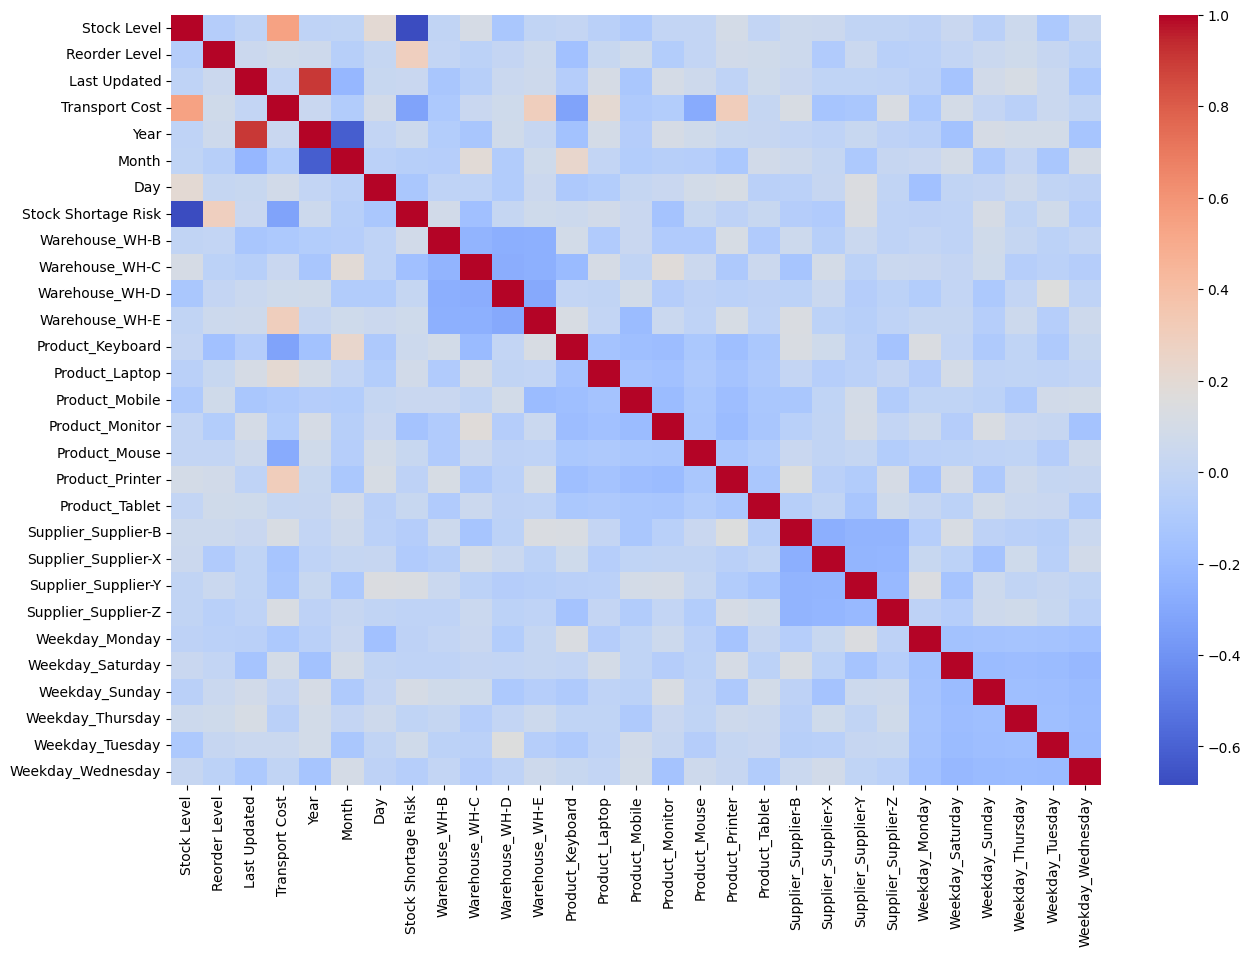

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.show()

In [41]:
df_encoded.head()
df_encoded = df_encoded.drop("Last Updated", axis=1)

### ML

### Regression : Transport Cost

In [ ]:
x_reg=df_encoded.drop(
  ["Transport Cost","Stock Shortage Risk"],axis=1
)

y_reg=df_encoded["Transport Cost"]

In [43]:
from sklearn.model_selection import train_test_split
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(
  x_reg,y_reg,random_state=42,test_size=0.2
)

In [44]:
x_train_reg.shape
x_test_reg.shape

(40, 26)

### Classification : Stock Shortage Risk

In [45]:
x_cls=df_encoded.drop(
  ['Stock Shortage Risk','Transport Cost']
  ,axis=1
)
y_cls=df_encoded['Stock Shortage Risk']

In [46]:
x_train_cls,x_test_cls,y_train_cls,y_test_cls=train_test_split(
  x_cls,y_cls,random_state=42,test_size=0.2
)

### 1 Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

In [48]:
lr=LinearRegression()
lr.fit(
  x_train_reg,y_train_reg
)

y_prediction_reg=lr.predict(x_test_reg)
print(y_prediction_reg)

[2011.682423   1308.31064103 1680.26561492 2930.91655115 1628.51590521
 2114.87219423 1064.60778194 2629.44518882 2071.96512779 2470.44892038
 1735.75744628 2205.01855184 2244.45092952 2773.65821843 2933.83644744
 2454.69802903 2141.49597855 3118.70118881 3167.01745903 2156.3902571
 2686.68032955 3137.91114724 1927.33569753 2620.80561428 1574.82113621
 1712.31248807 3054.84050495 2872.73965509 3462.47834425 1903.015257
 2055.82594461 2620.64572397 2690.62579352 2008.82792295 3801.98768788
 3347.96757448 3405.84547705 2530.11744306 2885.19742089 2237.7016066 ]


In [49]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [50]:
mean_absolute_error(y_test_reg,y_prediction_reg)

250.60501774104924

In [51]:
mean_squared_error(y_test_reg,y_prediction_reg)

124890.28605128056

In [52]:
r2_score(y_test_reg,y_prediction_reg)

0.7823835750850472

### PART B : CLASSIFICATION

 #### 1 Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
log_model=LogisticRegression()
log_model.fit(
  x_train_cls,
  y_train_cls
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
y_prediction_classi=log_model.predict(x_test_cls)
print(y_prediction_classi)

[0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0
 0 0 0]


In [61]:
from sklearn.metrics import r2_score , accuracy_score , f1_score , precision_score  , recall_score 


In [62]:
print("Accuracy :", accuracy_score(y_test_cls, y_prediction_classi))

print("Precision :", precision_score(y_test_cls, y_prediction_classi))

print("Recall :", recall_score(y_test_cls, y_prediction_classi))

print("F1 :", f1_score(y_test_cls, y_prediction_classi))

print("R2 Score :", r2_score(y_test_cls,y_prediction_classi))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 : 1.0
R2 Score : 1.0
